# OCT wetAMD ROI-Guided Segmentation(Crop ROI)



## Step 0 -- Install Dependencies

In [1]:
!pip install -q segmentation-models-pytorch albumentations ultralytics
!pip install -q fvcore 2>/dev/null || true
print("Dependencies installed")
!pip install -q pynvml 2>/dev/null || true


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 28.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 3.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
Dependencies installed
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 4.4 MB/s eta 0:00:00


## Step 1 -- Imports & Configuration



In [73]:
import os, cv2, json, time, random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import pandas as pd
import segmentation_models_pytorch as smp
import albumentations as A
from albumentations.pytorch import ToTensorV2
from ultralytics import YOLO
from pathlib import Path
from google.colab import drive

# ── CONFIG -- edit only this cell ────────────────────────────────────────────
CONFIG = {
    # ── Dataset ───────────────────────────────────────────────────────────────
    "image_dir"         : "/content/drive/MyDrive/FYP/data/images",
    "mask_dir"          : "/content/drive/MyDrive/FYP/data/masks",
    "test_fraction"     : 0.2,
    "seed"              : 42,

    # ── Models ────────────────────────────────────────────────────────────────
    "yolo_weights"      : "/content/drive/MyDrive/FYP/model/yolo_runs/roi_detect/weights/best.pt",
    "seg_weights"       : "/content/drive/MyDrive/FYP/model/finetune_unetpp_roi_best.pth",

    # ── Architecture ──────────────────────────────────────────────────────────
    "num_classes"       : 6,

    "baseline_input_size" : 256,
    "full_img_h"          : 380,
    "full_img_w"          : 570,

    # ── YOLO detection ────────────────────────────────────────────────────────
    "yolo_conf"           : 0.25,
    "yolo_iou"            : 0.45,
    "yolo_imgsz"          : 640,

    # ── ROI crop padding  ─────
    "x_pad_frac"          : 0.15,
    "y_pad_frac"          : 0.2,

    # ── Output paths (Drive) ──────────────────────────────────────────────────
    "output_dir"          : "/content/drive/MyDrive/FYP/crop_roi/ft",
    "pred_mask_dir"       : "/content/drive/MyDrive/FYP/crop_roi/ft/pred_masks",
    "viz_dir"             : "/content/drive/MyDrive/FYP/crop_roi/ft/visualisations",
    "metrics_csv"         : "/content/drive/MyDrive/FYP/crop_roi/ft/metrics.csv",
    "summary_json"        : "/content/drive/MyDrive/FYP/crop_roi/ft/summary.json",
}

NUM_CLASSES = CONFIG["num_classes"]
CLASS_NAMES = ["Background", "Retinal Layer", "PED", "SRF", "IRF", "RPE"]

# ── Compute anisotropic scale factors once at startup ────────────────────────
SCALE_H = CONFIG["baseline_input_size"] / CONFIG["full_img_h"]
SCALE_W = CONFIG["baseline_input_size"] / CONFIG["full_img_w"]


BASELINE_SCALE = SCALE_W

torch.manual_seed(CONFIG["seed"])
np.random.seed(CONFIG["seed"])
random.seed(CONFIG["seed"])

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device         : {device}")
if torch.cuda.is_available():
    print(f"GPU            : {torch.cuda.get_device_name(0)}")
print(f"NUM_CLASSES    : {NUM_CLASSES}")
print(f"SCALE_H        : {SCALE_H:.4f}  (= {CONFIG['baseline_input_size']} / {CONFIG['full_img_h']}  -- height axis)")
print(f"SCALE_W        : {SCALE_W:.4f}  (= {CONFIG['baseline_input_size']} / {CONFIG['full_img_w']}  -- width  axis)")
print(f"Example: crop 52x547 (HxW) ->")
print(f"  new_h = round(52  * {SCALE_H:.4f}) = {round(52*SCALE_H)}  -> snap32 -> {int(np.ceil(max(32,round(52*SCALE_H))/32)*32)}")
print(f"  new_w = round(547 * {SCALE_W:.4f}) = {round(547*SCALE_W)}  -> snap32 -> {int(np.ceil(max(32,round(547*SCALE_W))/32)*32)}")


Device         : cpu
NUM_CLASSES    : 6
SCALE_H        : 0.6737  (= 256 / 380  -- height axis)
SCALE_W        : 0.4491  (= 256 / 570  -- width  axis)
Example: crop 52x547 (HxW) ->
  new_h = round(52  * 0.6737) = 35  -> snap32 -> 64
  new_w = round(547 * 0.4491) = 246  -> snap32 -> 256


## Step 2 -- Mount Google Drive & Create Output Directories

In [91]:
drive.mount("/content/drive")

for d in [CONFIG["output_dir"], CONFIG["pred_mask_dir"], CONFIG["viz_dir"]]:
    os.makedirs(d, exist_ok=True)
    print(f"  {d}")
print("Drive mounted. Output directories ready.")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
  /content/drive/MyDrive/FYP/crop_roi/ft
  /content/drive/MyDrive/FYP/crop_roi/ft/pred_masks
  /content/drive/MyDrive/FYP/crop_roi/ft/visualisations
Drive mounted. Output directories ready.


## Step 3 -- Class Mapping & Helper Functions



In [4]:
CLASS_INFO = {
    0: {"name": "Background",    "rgb": (0,   0,   0)},
    1: {"name": "Retinal Layer", "rgb": (255, 0,   255)},
    2: {"name": "PED",           "rgb": (255, 255, 0)},
    3: {"name": "SRF",           "rgb": (255, 0,   0)},
    4: {"name": "IRF",           "rgb": (0,   0,   255)},
    5: {"name": "RPE",           "rgb": (0,   255, 0)},
}

CLASS_COLORS_VIZ = [
    [0,   0,   0  ],
    [255, 0,   255],
    [255, 255, 0  ],
    [255, 0,   0  ],
    [0,   0,   255],
    [0,   255, 0  ],
]

print("-- Class Mapping ---------------------------------------------------")
for cls_id, info in CLASS_INFO.items():
    r, g, b = info["rgb"]
    print(f"  Class {cls_id}: {info['name']:<18} RGB({r:3d},{g:3d},{b:3d})")


def rgb_mask_to_class(mask_bgr, class_info=CLASS_INFO, tolerance=40):
    """Convert a BGR colour mask to an integer class label map (H, W)."""
    mask_rgb  = cv2.cvtColor(mask_bgr, cv2.COLOR_BGR2RGB)
    h, w, _   = mask_rgb.shape
    pixels    = mask_rgb.reshape(-1, 3).astype(np.float32)
    best_dist = np.full(len(pixels), np.inf)
    best_cls  = np.zeros(len(pixels), dtype=np.uint8)
    for cls_id, info in class_info.items():
        ref  = np.array(info["rgb"], dtype=np.float32)
        dist = np.linalg.norm(pixels - ref, axis=1)
        better = dist < best_dist
        best_dist[better] = dist[better]
        best_cls[better]  = cls_id
    return best_cls.reshape(h, w)


def mask_to_rgb(mask_np):
    """Integer class map to RGB visualisation array."""
    h, w = mask_np.shape
    rgb  = np.zeros((h, w, 3), dtype=np.uint8)
    for c in range(NUM_CLASSES):
        rgb[mask_np == c] = CLASS_COLORS_VIZ[c]
    return rgb


def dice_score_np(pred_cls, gt_cls, smooth=1e-6):
    scores = []
    for c in range(NUM_CLASSES):
        p = (pred_cls == c).astype(np.float32)
        t = (gt_cls   == c).astype(np.float32)
        inter = (p * t).sum()
        scores.append((2*inter+smooth) / (p.sum()+t.sum()+smooth))
    return float(np.mean(scores))

def iou_score_np(pred_cls, gt_cls, smooth=1e-6):
    scores = []
    for c in range(NUM_CLASSES):
        p = (pred_cls == c).astype(np.float32)
        t = (gt_cls   == c).astype(np.float32)
        inter = (p * t).sum()
        union = p.sum() + t.sum() - inter
        scores.append((inter+smooth) / (union+smooth))
    return float(np.mean(scores))

def pixel_accuracy_np(pred_cls, gt_cls):
    return float((pred_cls == gt_cls).mean())

def sensitivity_specificity_np(pred_cls, gt_cls, smooth=1e-6):
    sens_list, spec_list = [], []
    for c in range(NUM_CLASSES):
        tp = float(((pred_cls == c) & (gt_cls == c)).sum())
        fn = float(((pred_cls != c) & (gt_cls == c)).sum())
        tn = float(((pred_cls != c) & (gt_cls != c)).sum())
        fp = float(((pred_cls == c) & (gt_cls != c)).sum())
        sens_list.append((tp+smooth)/(tp+fn+smooth))
        spec_list.append((tn+smooth)/(tn+fp+smooth))
    return float(np.mean(sens_list)), float(np.mean(spec_list))

def per_class_dice_np(pred_cls, gt_cls, smooth=1e-6):
    scores = []
    for c in range(NUM_CLASSES):
        p = (pred_cls == c).astype(np.float32)
        t = (gt_cls   == c).astype(np.float32)
        inter = (p * t).sum()
        scores.append(float((2*inter+smooth)/(p.sum()+t.sum()+smooth)))
    return scores

def per_class_iou_np(pred_cls, gt_cls, smooth=1e-6):
    scores = []
    for c in range(NUM_CLASSES):
        p = (pred_cls == c).astype(np.float32)
        t = (gt_cls   == c).astype(np.float32)
        inter = (p * t).sum()
        union = p.sum() + t.sum() - inter
        scores.append(float((inter+smooth)/(union+smooth)))
    return scores

print("\nHelper functions defined.")


-- Class Mapping ---------------------------------------------------
  Class 0: Background         RGB(  0,  0,  0)
  Class 1: Retinal Layer      RGB(255,  0,255)
  Class 2: PED                RGB(255,255,  0)
  Class 3: SRF                RGB(255,  0,  0)
  Class 4: IRF                RGB(  0,  0,255)
  Class 5: RPE                RGB(  0,255,  0)

Helper functions defined.


## Step 4 -- Load 20% Test Subset



In [78]:
IMG_EXTS = ('.png', '.jpg', '.jpeg', '.tif', '.bmp')

all_images = sorted([
    f for f in os.listdir(CONFIG["image_dir"])
    if f.lower().endswith(IMG_EXTS)
])

paired = []
for fname in all_images:
    mask_path = os.path.join(CONFIG["mask_dir"], fname)
    if os.path.exists(mask_path):
        paired.append(fname)
    else:
        stem = os.path.splitext(fname)[0]
        for ext in IMG_EXTS:
            if os.path.exists(os.path.join(CONFIG["mask_dir"], stem + ext)):
                paired.append(fname)
                break

print(f"Total paired files : {len(paired)}")

rng = random.Random(CONFIG["seed"])
rng.shuffle(paired)
n_subset   = max(1, int(len(paired) * CONFIG["test_fraction"]))
test_files = paired[:n_subset]

print(f"20% subset size    : {n_subset} images  (seed={CONFIG['seed']})")
for f in test_files[:5]:
    print(f"  {f}")


Total paired files : 3049
20% subset size    : 609 images  (seed=42)
  2506.png
  1531.png
  103.png
  1594.png
  2881.png


## Step 5 -- Load YOLOv8n ROI Detector



In [6]:
yolo_path = CONFIG["yolo_weights"]
assert os.path.exists(yolo_path), f"YOLO weights not found:\n  {yolo_path}"

yolo_model = YOLO(yolo_path)
yolo_model.to(device)

n_yolo_params = sum(p.numel() for p in yolo_model.model.parameters())
print(f"YOLOv8n -- {n_yolo_params:,} params ({n_yolo_params/1e6:.2f}M)")
print(f"  Conf thr : {CONFIG['yolo_conf']}  |  IoU thr : {CONFIG['yolo_iou']}")
print("YOLOv8n loaded.")


YOLOv8n -- 3,011,043 params (3.01M)
  Conf thr : 0.3  |  IoU thr : 0.45
YOLOv8n loaded.


## Step 6 -- Load UNet++ Segmentation Model



In [35]:
seg_model = smp.UnetPlusPlus(
    encoder_name          = "efficientnet-b4",
    encoder_weights       = None,
    in_channels           = 1,
    classes               = NUM_CLASSES,
    activation            = None,
    decoder_channels      = (256, 128, 64, 32, 16),
    decoder_use_batchnorm = True,
)
seg_model = seg_model.to(device)

seg_path = CONFIG["seg_weights"]
assert os.path.exists(seg_path), f"Checkpoint not found:\n  {seg_path}"

ckpt = torch.load(seg_path, map_location=device)
seg_model.load_state_dict(ckpt["model_state"])
seg_model.eval()

n_seg_params = sum(p.numel() for p in seg_model.parameters())
print(f"UNet++ EfficientNet-B4")
print(f"  Epoch    : {ckpt.get('epoch', '?')}")
print(f"  Val Dice : {ckpt.get('dice',  '?')}")
print(f"  Params   : {n_seg_params:,} ({n_seg_params/1e6:.2f}M)")
print("Segmentation model loaded.")


def pad_to_stride32(img_np_gray):
    """Pad (H, W) numpy image so both dims are divisible by 32."""
    h, w   = img_np_gray.shape
    ph     = int(np.ceil(h / 32) * 32)
    pw     = int(np.ceil(w / 32) * 32)
    padded = np.zeros((ph, pw), dtype=img_np_gray.dtype)
    padded[:h, :w] = img_np_gray
    return padded, (h, w)


UNet++ EfficientNet-B4
  Epoch    : 69
  Val Dice : 0.7855338569219947
  Params   : 20,812,974 (20.81M)
Segmentation model loaded.


## Step 7 -- ROI Detection Function



In [74]:
def detect_roi(img_bgr, yolo_model, conf=0.25, iou=0.45, imgsz=640):

    #Run YOLOv8n; return best box, confidence, detected flag
    H, W = img_bgr.shape[:2]
    results = yolo_model.predict(
        img_bgr, conf=conf, iou=iou, imgsz=imgsz, verbose=False,
    )[0]
    if results.boxes is None or len(results.boxes) == 0:
        return (0, 0, W, H), 0.0, False
    boxes     = results.boxes
    conf_vals = boxes.conf.cpu().numpy()
    best_idx  = int(np.argmax(conf_vals))
    x1, y1, x2, y2 = map(int, boxes.xyxy[best_idx].cpu().numpy())
    x1, y1 = max(0, x1), max(0, y1)
    x2, y2 = min(W, x2), min(H, y2)
    return (x1, y1, x2, y2), float(conf_vals[best_idx]), True


# Smoke-test
_fname    = test_files[0]
_img_bgr  = cv2.imread(os.path.join(CONFIG["image_dir"], _fname))
_box, _c, _det = detect_roi(
    _img_bgr, yolo_model,
    conf=CONFIG["yolo_conf"], iou=CONFIG["yolo_iou"], imgsz=CONFIG["yolo_imgsz"],
)
print(f"Smoke-test : {_fname}")
print(f"  Detected : {_det}  conf={_c:.3f}  box={_box}")
print(f"  Box size : {_box[2]-_box[0]}x{_box[3]-_box[1]} (WxH)")


Smoke-test : 906.png
  Detected : True  conf=0.786  box=(0, 118, 568, 186)
  Box size : 568x68 (WxH)


## Step 8 -- Anisotropic Scale Utilities




In [57]:
def compute_proportional_size(h_crop, w_crop, scale_h, scale_w, min_side=32):
    """Compute the anisotropic segmentation input size for a ROI crop.

    Applies the EXACT same height and width scale factors the baseline used
    when it resized the full 380x570 OCT image to 256x256:
        scale_h = 256 / 380 = 0.6737
        scale_w = 256 / 570 = 0.4491

    Both dimensions are then snapped up to the nearest multiple of 32
    to satisfy EfficientNet-B4's encoder stride requirement.

    Parameters
    ----------
    h_crop, w_crop : native ROI crop dimensions (pixels)
    scale_h        : float -- height scale factor  (SCALE_H = 256/380)
    scale_w        : float -- width  scale factor  (SCALE_W = 256/570)
    min_side       : int   -- minimum output dimension (default 32)

    Returns
    -------
    (h_scaled, w_scaled) : target input size for UNet++
    """
    # Apply each axis scale independently -- this matches the baseline training
    h_raw = max(min_side, round(h_crop * scale_h))
    w_raw = max(min_side, round(w_crop * scale_w))

    # Snap up to the next multiple of 32
    h_scaled = int(np.ceil(h_raw / 32) * 32)
    w_scaled = int(np.ceil(w_raw / 32) * 32)

    return h_scaled, w_scaled


def resize_pred_to_native(pred_scaled, h_orig, w_orig):
    """Resize the scaled prediction mask back to native crop dimensions.

    Uses INTER_NEAREST to preserve discrete integer class labels (0-5).
    INTER_LINEAR or INTER_CUBIC would blend class IDs and produce invalid
    fractional values between class indices.

    Parameters
    ----------
    pred_scaled : np.ndarray (h_scaled, w_scaled) uint8
    h_orig, w_orig : native crop dimensions

    Returns
    -------
    pred_native : np.ndarray (h_orig, w_orig) uint8
    """
    if pred_scaled.shape == (h_orig, w_orig):
        return pred_scaled  # already the right size
    return cv2.resize(
        pred_scaled,
        (w_orig, h_orig),          # cv2 takes (width, height)
        interpolation=cv2.INTER_NEAREST
    ).astype(np.uint8)


# ── Smoke-test: show the correct vs old scaling on the test image ────────────
_img_gray = cv2.imread(os.path.join(CONFIG["image_dir"], _fname), cv2.IMREAD_GRAYSCALE)
_crop_sm, _coords_sm = (
    lambda img, box: (
        img[
            max(0, box[1] - int(round((box[3]-box[1])*CONFIG["y_pad_frac"]))):
            min(img.shape[0], box[3] + int(round((box[3]-box[1])*CONFIG["y_pad_frac"]))),
            max(0, box[0] - int(round((box[2]-box[0])*CONFIG["x_pad_frac"]))):
            min(img.shape[1], box[2] + int(round((box[2]-box[0])*CONFIG["x_pad_frac"]))),
        ],
        (
            max(0, box[0] - int(round((box[2]-box[0])*CONFIG["x_pad_frac"]))),
            max(0, box[1] - int(round((box[3]-box[1])*CONFIG["y_pad_frac"]))),
            min(img.shape[1], box[2] + int(round((box[2]-box[0])*CONFIG["x_pad_frac"]))),
            min(img.shape[0], box[3] + int(round((box[3]-box[1])*CONFIG["y_pad_frac"]))),
        )
    )
)(_img_gray, _box)

_h_c, _w_c = _crop_sm.shape

# New: anisotropic scale (correct)
_h_s, _w_s = compute_proportional_size(_h_c, _w_c, SCALE_H, SCALE_W)

# Old: single-scale (for comparison)
_h_s_old = int(np.ceil(max(32, round(_h_c * BASELINE_SCALE)) / 32) * 32)
_w_s_old = int(np.ceil(max(32, round(_w_c * BASELINE_SCALE)) / 32) * 32)

# Native-pad (original pipeline, for reference)
_h_native_pad = int(np.ceil(_h_c / 32) * 32)
_w_native_pad = int(np.ceil(_w_c / 32) * 32)

print("-- Anisotropic Scaling Smoke-Test ----------------------------------")
print(f"  Full image          : {_img_gray.shape}  (H x W)")
print(f"  SCALE_H             : {SCALE_H:.4f}  (= 256 / {CONFIG['full_img_h']})")
print(f"  SCALE_W             : {SCALE_W:.4f}  (= 256 / {CONFIG['full_img_w']})")
print(f"  Crop (native)       : {_h_c} x {_w_c}")
print(f"  Native padded       : {_h_native_pad} x {_w_native_pad}   <-- v1 input (too large)")
print(f"  Single-scale (old)  : {_h_s_old} x {_w_s_old}   <-- v3 input (under-scales H)")
print(f"  Anisotropic (new)   : {_h_s} x {_w_s}  <-- correct, matches baseline training")
print()
print(f"  Crop H: {_h_c} * SCALE_H {SCALE_H:.4f} = {_h_c*SCALE_H:.1f} -> snap32 -> {_h_s}")
print(f"  Crop W: {_w_c} * SCALE_W {SCALE_W:.4f} = {_w_c*SCALE_W:.1f} -> snap32 -> {_w_s}")


-- Anisotropic Scaling Smoke-Test ----------------------------------
  Full image          : (380, 570)  (H x W)
  SCALE_H             : 0.6737  (= 256 / 380)
  SCALE_W             : 0.4491  (= 256 / 570)
  Crop (native)       : 66 x 570
  Native padded       : 96 x 576   <-- v1 input (too large)
  Single-scale (old)  : 32 x 256   <-- v3 input (under-scales H)
  Anisotropic (new)   : 64 x 256  <-- correct, matches baseline training

  Crop H: 66 * SCALE_H 0.6737 = 44.5 -> snap32 -> 64
  Crop W: 570 * SCALE_W 0.4491 = 256.0 -> snap32 -> 256


## Step 9 -- Segmentation Inference



In [10]:
def segment_roi(crop_gray, seg_model, device,
                scale_h=None, scale_w=None):
    """Segmentation inference with anisotropic (separate H/W) scaling.

    Resizes the ROI crop using the EXACT same height and width scale factors
    the baseline applied when training (380x570 -> 256x256):
        scale_h = 256 / 380 = 0.6737
        scale_w = 256 / 570 = 0.4491

    Parameters
    ----------
    crop_gray : np.ndarray (H_c, W_c) uint8   -- native ROI crop
    seg_model : nn.Module                      -- UNet++ in eval mode
    device    : torch.device
    scale_h   : float -- height scale factor (default: SCALE_H global)
    scale_w   : float -- width  scale factor (default: SCALE_W global)

    Returns
    -------
    pred_cls : np.ndarray (H_c, W_c) uint8  -- class map at native crop size
    """
    h_orig, w_orig = crop_gray.shape

    # Fall back to global scale factors computed at startup
    if scale_h is None:
        scale_h = SCALE_H
    if scale_w is None:
        scale_w = SCALE_W

    # ── Step 1: Compute anisotropic target dimensions ────────────────────────
    h_scaled, w_scaled = compute_proportional_size(
        h_orig, w_orig, scale_h, scale_w
    )

    # ── Step 2: Resize crop to target (INTER_LINEAR = same as training) ──────
    crop_resized = cv2.resize(
        crop_gray,
        (w_scaled, h_scaled),      # cv2: (width, height)
        interpolation=cv2.INTER_LINEAR
    )  # (h_scaled, w_scaled) uint8

    # ── Step 3: Normalise -- identical to baseline get_transforms ────────────
    img_f = crop_resized.astype(np.float32)
    img_f = (img_f / 255.0 - 0.5) / 0.5    # -> [-1, 1]

    # ── Step 4: Build tensor and forward pass ─────────────────────────────────
    # h_scaled and w_scaled are already multiples of 32 (from compute_proportional_size)
    # so no additional stride-32 padding is needed here.
    tensor = (
        torch.tensor(img_f, dtype=torch.float32)
        .unsqueeze(0).unsqueeze(0).to(device)
    )  # (1, 1, h_scaled, w_scaled)

    with torch.no_grad():
        logits = seg_model(tensor)   # (1, C, h_scaled, w_scaled)

    # ── Step 5: Argmax -> class map at scaled resolution ─────────────────────
    pred_scaled = (
        logits.argmax(dim=1).squeeze(0).cpu().numpy().astype(np.uint8)
    )  # (h_scaled, w_scaled)

    # ── Step 6: Resize prediction back to native crop size ───────────────────
    # INTER_NEAREST preserves discrete class IDs (0-5) without blending.
    pred_cls = resize_pred_to_native(pred_scaled, h_orig, w_orig)

    return pred_cls   # (H_c, W_c) -- same shape as input crop


# ── Smoke-test ───────────────────────────────────────────────────────────────
_seg_start = time.time()
_roi_pred  = segment_roi(_crop_sm, seg_model, device,
                         scale_h=SCALE_H, scale_w=SCALE_W)
_seg_time  = time.time() - _seg_start

print(f"Crop input size    : {_crop_sm.shape}  (H x W) native")
print(f"Anisotropic scaled : {_h_s} x {_w_s}  (H*{SCALE_H:.4f}, W*{SCALE_W:.4f})")
print(f"Prediction output  : {_roi_pred.shape}  (back to native)")
print(f"Unique classes     : {np.unique(_roi_pred).tolist()}")
print(f"Seg inference time : {_seg_time*1000:.1f} ms")


Crop input size    : (92, 570)  (H x W) native
Anisotropic scaled : 64 x 256  (H*0.6737, W*0.4491)
Prediction output  : (92, 570)  (back to native)
Unique classes     : [0, 1, 3]
Seg inference time : 270.5 ms


## Step 10 -- Asymmetric Crop and Reconstruction



In [75]:
def crop_roi(img_gray, box, x_pad_frac=0.15, y_pad_frac=0.2):

    H, W = img_gray.shape
    x1, y1, x2, y2 = box
    box_w = x2 - x1
    box_h = y2 - y1

    pad_x = int(round(box_w * x_pad_frac))
    pad_y = int(round(box_h * y_pad_frac))

    cx1 = max(0, x1 - pad_x)
    cy1 = max(0, y1 - pad_y)
    cx2 = min(W, x2 + pad_x)
    cy2 = min(H, y2 + pad_y)

    crop        = img_gray[cy1:cy2, cx1:cx2]
    crop_coords = (cx1, cy1, cx2, cy2)
    return crop, crop_coords


def reconstruct_full_mask(roi_pred_cls, crop_coords, full_shape):

    H, W = full_shape
    cx1, cy1, cx2, cy2 = crop_coords
    full_mask = np.zeros((H, W), dtype=np.uint8)
    full_mask[cy1:cy2, cx1:cx2] = roi_pred_cls.astype(np.uint8)
    return full_mask


# ── Verify on smoke-test image ───────────────────────────────────────────────
_crop2, _coords2 = crop_roi(
    _img_gray, _box,
    x_pad_frac=CONFIG["x_pad_frac"],
    y_pad_frac=CONFIG["y_pad_frac"],
)
_h_s2, _w_s2 = compute_proportional_size(
    _crop2.shape[0], _crop2.shape[1], SCALE_H, SCALE_W
)
print(f"Full image     : {_img_gray.shape}")
print(f"YOLO box       : {_box}")
print(f"Crop (native)  : {_crop2.shape}  coords={_coords2}")
print(f"Proportional   : {_h_s2} x {_w_s2}  (segmentation input)")
print(f"x_pad={CONFIG['x_pad_frac']*100:.0f}%  y_pad={CONFIG['y_pad_frac']*100:.0f}%")
_dummy = np.ones(_crop2.shape, dtype=np.uint8)
_recon = reconstruct_full_mask(_dummy, _coords2, _img_gray.shape)
print(f"Reconstruction : {_recon.shape} -- matches full image")


Full image     : (380, 570)
YOLO box       : (0, 118, 568, 186)
Crop (native)  : (96, 570)  coords=(0, 104, 570, 200)
Proportional   : 96 x 256  (segmentation input)
x_pad=15%  y_pad=20%
Reconstruction : (380, 570) -- matches full image


## Step 11 -- Full Single-Image Pipeline



In [79]:
def run_pipeline(fname, image_dir, mask_dir,
                 yolo_model, seg_model, device, config,
                 scale_h=None, scale_w=None):

    if scale_h is None:
        scale_h = SCALE_H
    if scale_w is None:
        scale_w = SCALE_W

    t0 = time.time()

    # ── 1. Load image ─────────────────────────────────────────────────────────
    img_path  = os.path.join(image_dir, fname)
    mask_path = os.path.join(mask_dir,  fname)
    img_bgr   = cv2.imread(img_path,  cv2.IMREAD_COLOR)
    img_gray  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    mask_bgr  = cv2.imread(mask_path, cv2.IMREAD_COLOR)
    H, W = img_gray.shape
    mask_gt_cls = rgb_mask_to_class(mask_bgr)

    # ── 2. YOLO detect ────────────────────────────────────────────────────────
    t_det_start = time.time()
    box, confidence, detected = detect_roi(
        img_bgr, yolo_model,
        conf=config["yolo_conf"], iou=config["yolo_iou"], imgsz=config["yolo_imgsz"],
    )
    t_detect = time.time() - t_det_start

    # ── 3. Crop with asymmetric padding ───────────────────────────────────────
    t_crop_start = time.time()
    crop, crop_coords = crop_roi(
        img_gray, box,
        x_pad_frac=config["x_pad_frac"],
        y_pad_frac=config["y_pad_frac"],
    )
    t_crop = time.time() - t_crop_start
    cx1, cy1, cx2, cy2 = crop_coords

    # ── 4. Anisotropic-scale segmentation ─────────────────────────────────────
    h_seg_in, w_seg_in = compute_proportional_size(
        crop.shape[0], crop.shape[1], scale_h, scale_w
    )
    t_seg_start  = time.time()
    roi_pred_cls = segment_roi(crop, seg_model, device,
                               scale_h=scale_h, scale_w=scale_w)
    t_seg = time.time() - t_seg_start

    # ── 5. Reconstruct full-size mask ─────────────────────────────────────────
    t_recon_start = time.time()
    full_pred_cls = reconstruct_full_mask(roi_pred_cls, crop_coords, (H, W))
    t_recon = time.time() - t_recon_start

    t_total = time.time() - t0

    # ── 6a. PRIMARY metrics -- ROI region only ────────────────────────────────
    gt_roi  = mask_gt_cls[cy1:cy2, cx1:cx2]
    h_p, w_p = roi_pred_cls.shape
    gt_roi  = gt_roi[:h_p, :w_p]

    dice    = dice_score_np(roi_pred_cls, gt_roi)
    iou     = iou_score_np(roi_pred_cls,  gt_roi)
    pix_acc = pixel_accuracy_np(roi_pred_cls, gt_roi)
    sens, spec = sensitivity_specificity_np(roi_pred_cls, gt_roi)
    pc_dice = per_class_dice_np(roi_pred_cls, gt_roi)
    pc_iou  = per_class_iou_np(roi_pred_cls,  gt_roi)

    # ── 6b. SECONDARY metrics -- full image (ablation) ────────────────────────
    dice_full  = dice_score_np(full_pred_cls, mask_gt_cls)
    iou_full   = iou_score_np(full_pred_cls,  mask_gt_cls)
    pix_acc_full = pixel_accuracy_np(full_pred_cls, mask_gt_cls)
    sens_full, spec_full = sensitivity_specificity_np(full_pred_cls, mask_gt_cls)
    pc_dice_full = per_class_dice_np(full_pred_cls, mask_gt_cls)
    pc_iou_full  = per_class_iou_np(full_pred_cls,  mask_gt_cls)

    return {
        "fname"          : fname,
        "img_gray"       : img_gray,
        "img_bgr"        : img_bgr,
        "mask_gt_cls"    : mask_gt_cls,
        "box"            : box,
        "confidence"     : confidence,
        "detected"       : detected,
        "crop"           : crop,
        "crop_coords"    : crop_coords,
        "gt_roi"         : gt_roi,
        # actual UNet++ input size (for per-image FLOPs tracking)
        "seg_input_h"    : h_seg_in,
        "seg_input_w"    : w_seg_in,
        "roi_pred_cls"   : roi_pred_cls,
        "full_pred_cls"  : full_pred_cls,
        # PRIMARY metrics (ROI only)
        "dice"           : dice,
        "iou"            : iou,
        "pixel_acc"      : pix_acc,
        "sensitivity"    : sens,
        "specificity"    : spec,
        "per_class_dice" : pc_dice,
        "per_class_iou"  : pc_iou,
        # SECONDARY metrics (full image)
        "dice_full"           : dice_full,
        "iou_full"            : iou_full,
        "pixel_acc_full"      : pix_acc_full,
        "sensitivity_full"    : sens_full,
        "specificity_full"    : spec_full,
        "per_class_dice_full" : pc_dice_full,
        "per_class_iou_full"  : pc_iou_full,
        # timings
        "t_detect" : t_detect,
        "t_crop"   : t_crop,
        "t_seg"    : t_seg,
        "t_recon"  : t_recon,
        "t_total"  : t_total,
    }


# ── Smoke-test ───────────────────────────────────────────────────────────────
_r = run_pipeline(
    test_files[0], CONFIG["image_dir"], CONFIG["mask_dir"],
    yolo_model, seg_model, device, CONFIG,
    scale_h=SCALE_H, scale_w=SCALE_W,
)
cx1, cy1, cx2, cy2 = _r["crop_coords"]
print(f"Smoke-test : {_r['fname']}")
print(f"  Detected   : {_r['detected']}  conf={_r['confidence']:.3f}")
print(f"  Crop native: {_r['crop'].shape}")
print(f"  Seg input  : {_r['seg_input_h']} x {_r['seg_input_w']}  (proportional)")
print(f"  Dice       : {_r['dice']:.4f}")
print(f"  IoU        : {_r['iou']:.4f}")
print(f"  total ms   : {_r['t_total']*1000:.1f}")


Smoke-test : 2506.png
  Detected   : True  conf=0.334
  Crop native: (62, 570)
  Seg input  : 64 x 256  (proportional)
  Dice       : 0.6340
  IoU        : 0.5392
  total ms   : 652.6


## Step 12 -- Batch Evaluation Loop

Identical structure to original. Passes `baseline_scale=BASELINE_SCALE` to `run_pipeline`.

In [80]:
all_results = []
n_total     = len(test_files)
n_detected  = 0

print(f"Running pipeline on {n_total} images  ({CONFIG['test_fraction']*100:.0f}% subset)")
print(f"{'#':>5} {'File':<35} {'Det':>4} {'Dice':>7} {'IoU':>7} {'SegIn':>11} {'ms':>7}")
print("-" * 78)

for i, fname in enumerate(test_files):
    res = run_pipeline(
        fname,
        CONFIG["image_dir"], CONFIG["mask_dir"],
        yolo_model, seg_model, device, CONFIG,
        scale_h=SCALE_H, scale_w=SCALE_W,
    )
    all_results.append(res)
    if res["detected"]:
        n_detected += 1

    if (i + 1) % 10 == 0 or i == 0 or i == n_total - 1:
        print(f"{i+1:>5} {fname:<35} "
              f"{'checkmark' if res['detected'] else 'x':>4} "
              f"{res['dice']:>7.4f} "
              f"{res['iou']:>7.4f} "
              f"{res['seg_input_h']:>5}x{res['seg_input_w']:<5} "
              f"{res['t_total']*1000:>7.1f}")

print(f"\nDone. Detected ROI in {n_detected}/{n_total} images "
      f"({100*n_detected/n_total:.1f}%)")

# ── Summarise proportional input sizes ───────────────────────────────────────
seg_input_areas = [
    r["seg_input_h"] * r["seg_input_w"] for r in all_results
]
baseline_area = CONFIG["baseline_input_size"] ** 2
print(f"\n-- Seg input area vs baseline 256x256 ({baseline_area:,} px^2) --------")
print(f"  Mean area  : {np.mean(seg_input_areas):>8.0f} px^2  "
      f"({100*np.mean(seg_input_areas)/baseline_area:.1f}% of baseline)")
print(f"  Max area   : {np.max(seg_input_areas):>8.0f} px^2  "
      f"({100*np.max(seg_input_areas)/baseline_area:.1f}% of baseline)")
print(f"  Min area   : {np.min(seg_input_areas):>8.0f} px^2  "
      f"({100*np.min(seg_input_areas)/baseline_area:.1f}% of baseline)")


Running pipeline on 609 images  (20% subset)
    # File                                 Det    Dice     IoU       SegIn      ms
------------------------------------------------------------------------------
    1 2506.png                            checkmark  0.6340  0.5392    64x256     443.2
   10 2267.png                            checkmark  0.8524  0.7719   160x256     650.3
   20 1086.png                            checkmark  0.8430  0.7603   192x256     697.8
   30 2913.png                            checkmark  0.8263  0.7363    64x192     389.5
   40 2087.png                            checkmark  0.7202  0.6532   128x256     588.2
   50 2841.png                            checkmark  0.6844  0.6319    96x96      582.5
   60 344.png                             checkmark  0.7928  0.7642    64x224     469.5
   70 1013.png                               x  0.7036  0.6458   256x256    1193.5
   80 1223.png                            checkmark  0.7404  0.7118    96x256     486.5
   90 

## Step 13 -- Metrics Summary



In [81]:
dice_vals  = [r["dice"]        for r in all_results]
iou_vals   = [r["iou"]         for r in all_results]
pa_vals    = [r["pixel_acc"]   for r in all_results]
sens_vals  = [r["sensitivity"] for r in all_results]
spec_vals  = [r["specificity"] for r in all_results]
total_ms   = [r["t_total"]*1000 for r in all_results]
det_ms     = [r["t_detect"]*1000 for r in all_results]
seg_ms     = [r["t_seg"]*1000    for r in all_results]

def stat(lst):
    return np.mean(lst), np.std(lst)

dice_m, dice_s = stat(dice_vals)
iou_m,  iou_s  = stat(iou_vals)
pa_m,   pa_s   = stat(pa_vals)
sens_m, sens_s = stat(sens_vals)
spec_m, spec_s = stat(spec_vals)
fps_m          = 1000 / np.mean(total_ms)

BLOCK = chr(9608)
print("=" * 62)
print("          PIPELINE EVALUATION RESULTS (proportional-scale)")
print(f"          {n_total} images  ({CONFIG['test_fraction']*100:.0f}% subset, seed={CONFIG['seed']})")
print("=" * 62)
print(f"  Dice Score     : {dice_m:.4f} +/- {dice_s:.4f}")
print(f"  IoU            : {iou_m:.4f} +/- {iou_s:.4f}")
print(f"  Pixel Accuracy : {pa_m:.4f} +/- {pa_s:.4f}")
print(f"  Sensitivity    : {sens_m:.4f} +/- {sens_s:.4f}")
print(f"  Specificity    : {spec_m:.4f} +/- {spec_s:.4f}")
print("-" * 62)
print(f"  Detection rate : {100*n_detected/n_total:.1f}%  ({n_detected}/{n_total})")
print(f"  Avg detect ms  : {np.mean(det_ms):.1f}")
print(f"  Avg seg ms     : {np.mean(seg_ms):.1f}")
print(f"  Avg total ms   : {np.mean(total_ms):.1f}")
print(f"  FPS            : {fps_m:.2f}")
print("=" * 62)

pc_dice_all = np.array([r["per_class_dice"] for r in all_results]).mean(axis=0)
pc_iou_all  = np.array([r["per_class_iou"]  for r in all_results]).mean(axis=0)

print("\n-- Per-Class Dice --------------------------------------------------")
for name, score in zip(CLASS_NAMES, pc_dice_all):
    bar = BLOCK * int(score * 30)
    print(f"  {name:<18} {score:.4f}  {bar}")

print("\n-- Per-Class IoU ---------------------------------------------------")
for name, score in zip(CLASS_NAMES, pc_iou_all):
    bar = BLOCK * int(score * 30)
    print(f"  {name:<18} {score:.4f}  {bar}")


          PIPELINE EVALUATION RESULTS (proportional-scale)
          609 images  (20% subset, seed=42)
  Dice Score     : 0.7869 +/- 0.1279
  IoU            : 0.7231 +/- 0.1345
  Pixel Accuracy : 0.9505 +/- 0.0352
  Sensitivity    : 0.8916 +/- 0.0932
  Specificity    : 0.9768 +/- 0.0168
--------------------------------------------------------------
  Detection rate : 96.6%  (588/609)
  Avg detect ms  : 189.2
  Avg seg ms     : 313.1
  Avg total ms   : 644.7
  FPS            : 1.55

-- Per-Class Dice --------------------------------------------------
  Background         0.9729  █████████████████████████████
  Retinal Layer      0.6788  ████████████████████
  PED                0.7470  ██████████████████████
  SRF                0.7485  ██████████████████████
  IRF                0.7057  █████████████████████
  RPE                0.8687  ██████████████████████████

-- Per-Class IoU ---------------------------------------------------
  Background         0.9479  █████████████████████████

## Step 14 -- Visualisation Panel



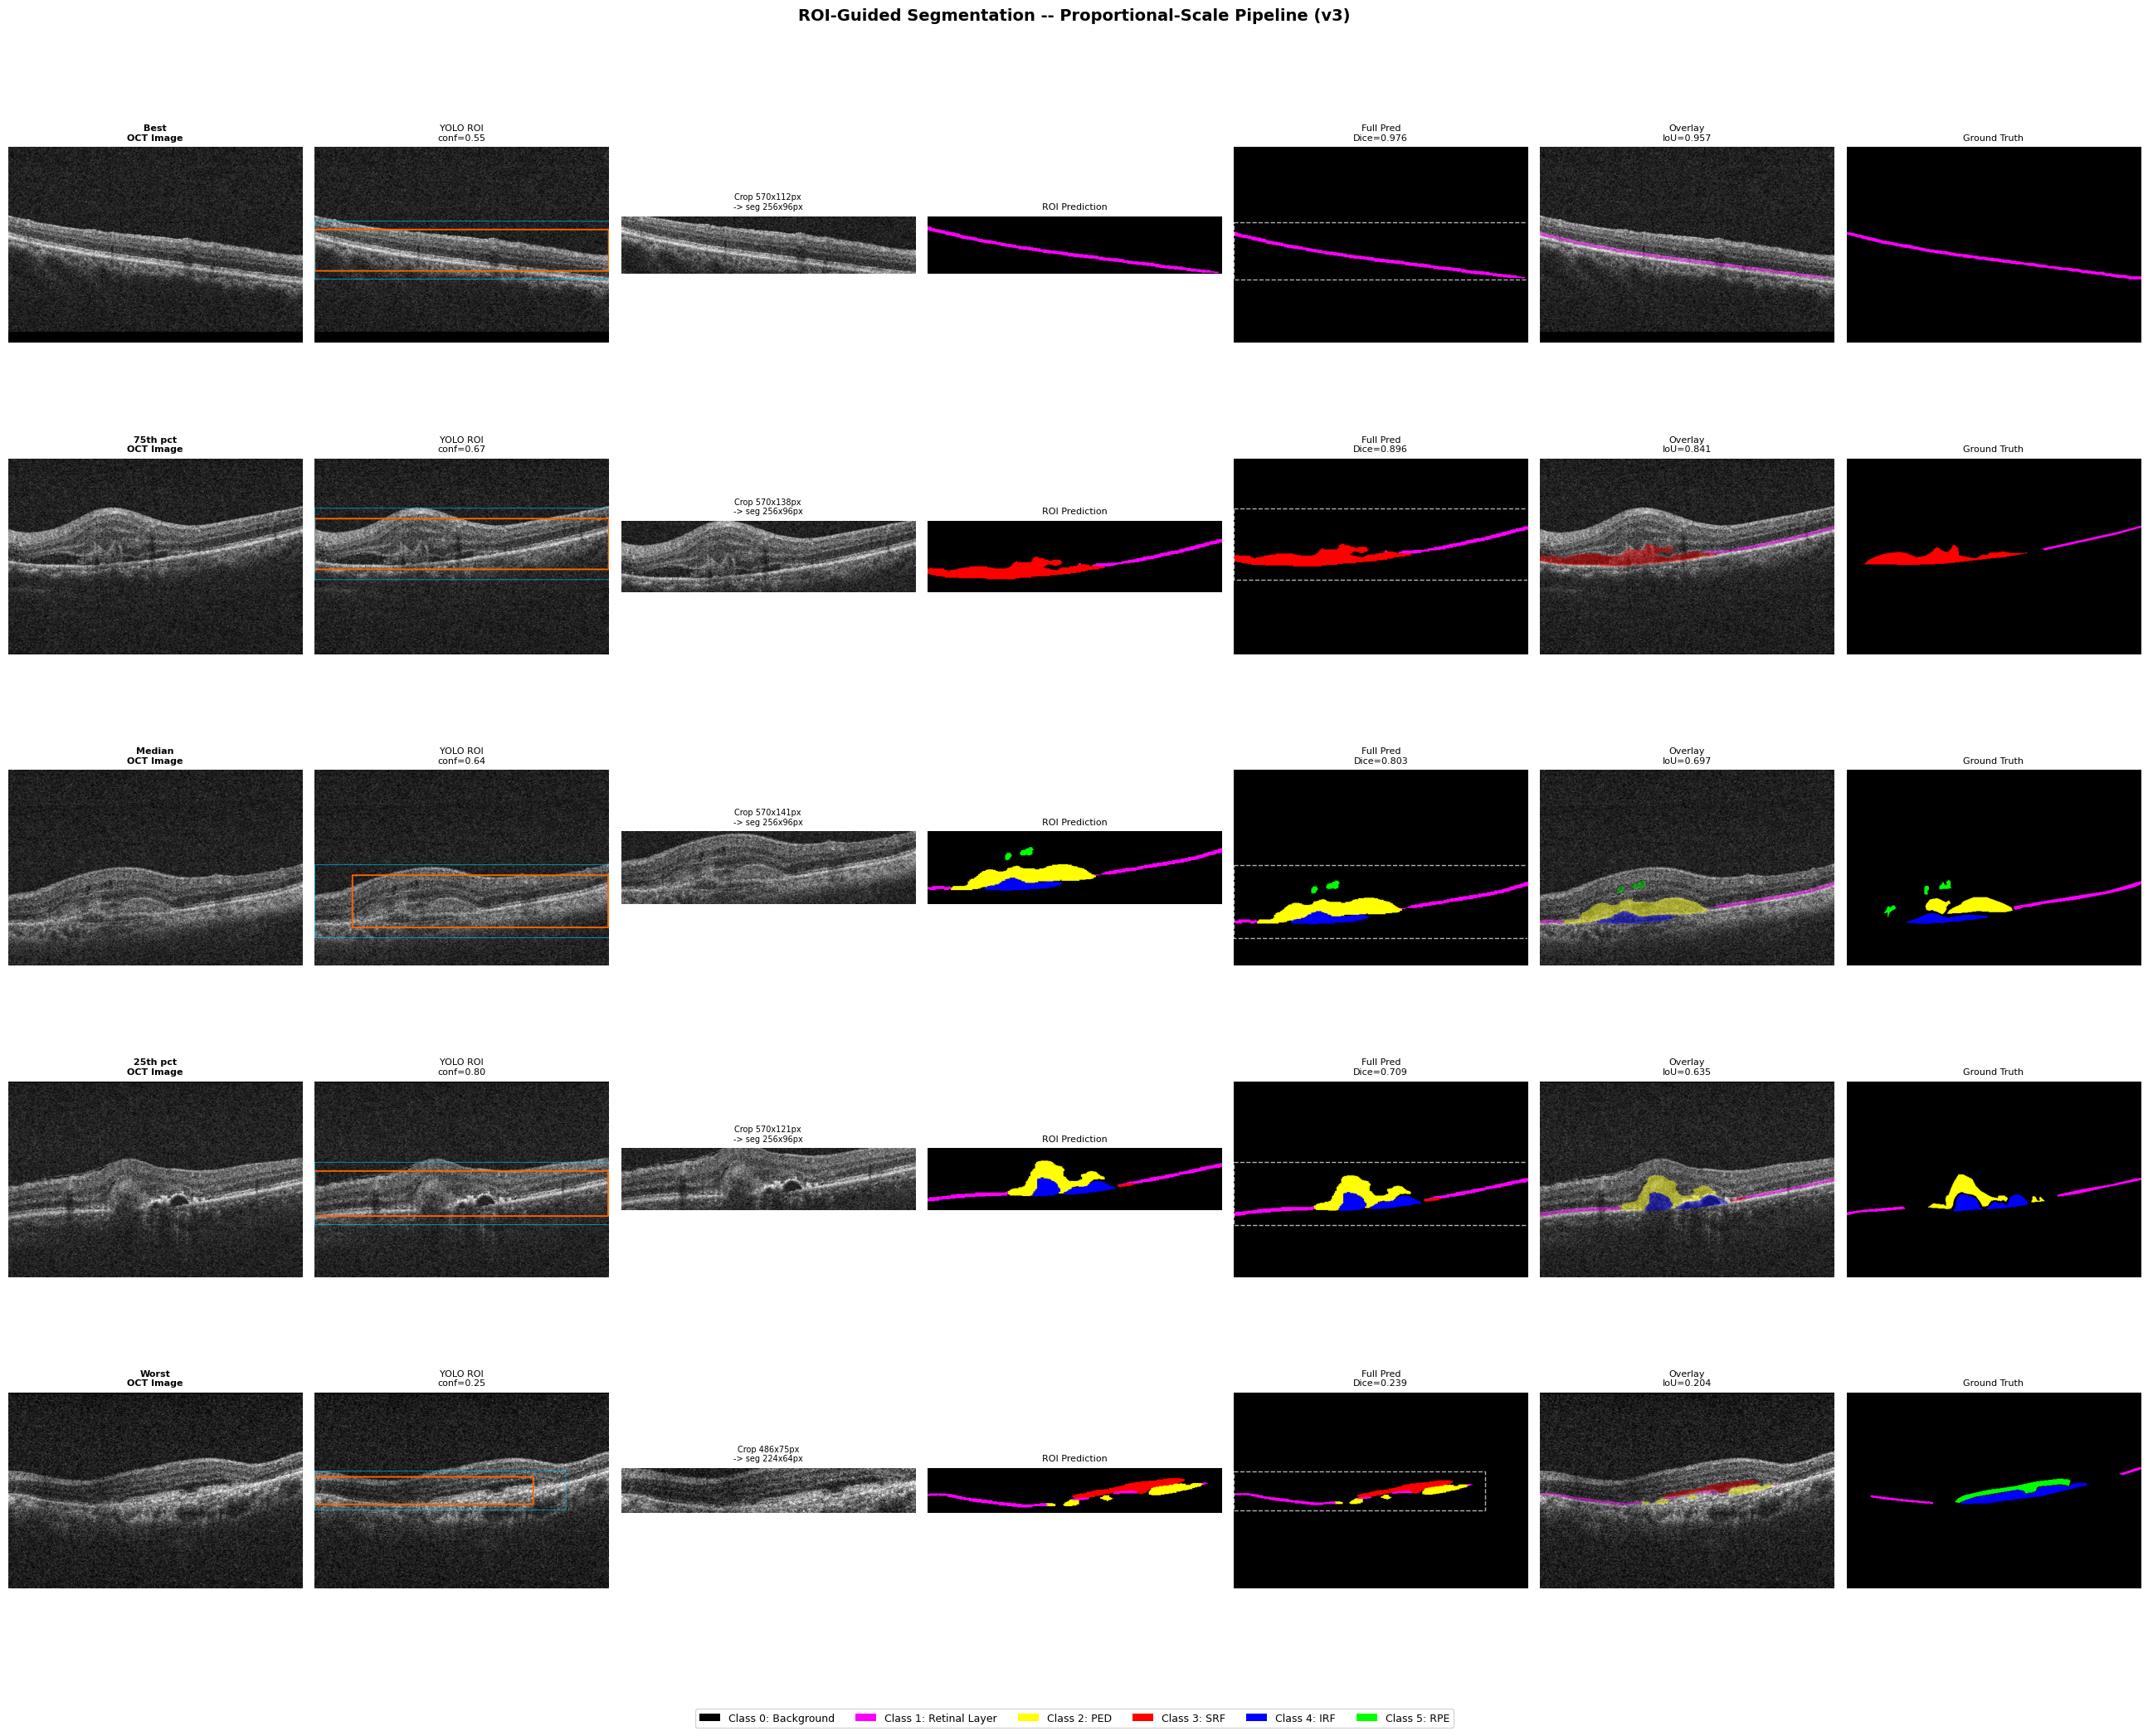

Saved -> /content/pipeline_viz_panel.png


In [82]:
N_VIZ = min(5, len(all_results))
sorted_by_dice = sorted(all_results, key=lambda r: r["dice"])
if len(all_results) >= 5:
    viz_results = [
        sorted_by_dice[-1],
        sorted_by_dice[len(sorted_by_dice)*3//4],
        sorted_by_dice[len(sorted_by_dice)//2],
        sorted_by_dice[len(sorted_by_dice)//4],
        sorted_by_dice[0],
    ]
else:
    viz_results = all_results[:N_VIZ]
labels = ["Best", "75th pct", "Median", "25th pct", "Worst"]

fig = plt.figure(figsize=(26, 4 * len(viz_results)))
fig.suptitle("ROI-Guided Segmentation -- Proportional-Scale Pipeline (v3)",
             fontsize=14, fontweight="bold", y=1.01)

n_cols = 7
for row_i, (res, label) in enumerate(zip(viz_results, labels)):
    img_gray  = res["img_gray"]
    img_bgr   = res["img_bgr"]
    box       = res["box"]
    crop      = res["crop"]
    cx1, cy1, cx2, cy2 = res["crop_coords"]
    roi_pred  = res["roi_pred_cls"]
    full_pred = res["full_pred_cls"]
    gt_cls    = res["mask_gt_cls"]

    ax = fig.add_subplot(len(viz_results), n_cols, row_i*n_cols + 1)
    ax.imshow(img_gray, cmap="gray")
    ax.set_title(f"{label}\nOCT Image", fontsize=8, fontweight="bold")
    ax.axis("off")

    ax = fig.add_subplot(len(viz_results), n_cols, row_i*n_cols + 2)
    vis_box = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB).copy()
    x1,y1,x2,y2 = box
    cv2.rectangle(vis_box, (x1,y1),(x2,y2), (255,100,0), 2)
    cv2.rectangle(vis_box, (cx1,cy1),(cx2,cy2), (0,200,255), 1)
    conf_str = f"{res['confidence']:.2f}" if res["detected"] else "fallback"
    ax.imshow(vis_box)
    ax.set_title(f"YOLO ROI\nconf={conf_str}", fontsize=8)
    ax.axis("off")

    ax = fig.add_subplot(len(viz_results), n_cols, row_i*n_cols + 3)
    ax.imshow(crop, cmap="gray")
    ax.set_title(
        f"Crop {crop.shape[1]}x{crop.shape[0]}px\n"
        f"-> seg {res['seg_input_w']}x{res['seg_input_h']}px",
        fontsize=7
    )
    ax.axis("off")

    ax = fig.add_subplot(len(viz_results), n_cols, row_i*n_cols + 4)
    ax.imshow(mask_to_rgb(roi_pred))
    ax.set_title("ROI Prediction", fontsize=8)
    ax.axis("off")

    ax = fig.add_subplot(len(viz_results), n_cols, row_i*n_cols + 5)
    ax.imshow(mask_to_rgb(full_pred))
    rect = plt.Rectangle((cx1,cy1),cx2-cx1,cy2-cy1,
                          linewidth=1,edgecolor="white",facecolor="none",
                          linestyle="--",alpha=0.7)
    ax.add_patch(rect)
    ax.set_title(f"Full Pred\nDice={res['dice']:.3f}", fontsize=8)
    ax.axis("off")

    ax = fig.add_subplot(len(viz_results), n_cols, row_i*n_cols + 6)
    oct_rgb  = cv2.cvtColor(img_gray, cv2.COLOR_GRAY2RGB).astype(np.float32)
    pred_rgb = mask_to_rgb(full_pred).astype(np.float32)
    fg       = (full_pred != 0)[..., None]
    overlay  = np.where(fg, 0.55*oct_rgb+0.45*pred_rgb, oct_rgb).clip(0,255).astype(np.uint8)
    ax.imshow(overlay)
    ax.set_title(f"Overlay\nIoU={res['iou']:.3f}", fontsize=8)
    ax.axis("off")

    ax = fig.add_subplot(len(viz_results), n_cols, row_i*n_cols + 7)
    ax.imshow(mask_to_rgb(gt_cls))
    ax.set_title("Ground Truth", fontsize=8)
    ax.axis("off")

legend_elements = [
    mpatches.Patch(facecolor=np.array(CLASS_COLORS_VIZ[i])/255,
                   label=f"Class {i}: {CLASS_NAMES[i]}")
    for i in range(NUM_CLASSES)
]
fig.legend(handles=legend_elements, loc="lower center",
           ncol=6, fontsize=9, bbox_to_anchor=(0.5, -0.03))
plt.tight_layout()
viz_path = "/content/pipeline_viz_panel.png"
plt.savefig(viz_path, dpi=130, bbox_inches="tight")
plt.show()
print(f"Saved -> {viz_path}")


## Step 15 -- Performance Profiling



In [83]:
n_yolo_p  = sum(p.numel() for p in yolo_model.model.parameters())
n_seg_p   = sum(p.numel() for p in seg_model.parameters())
n_total_p = n_yolo_p + n_seg_p

print("-- Model Parameters ------------------------------------------------")
print(f"  YOLOv8n          : {n_yolo_p:>12,}  ({n_yolo_p/1e6:.2f}M)")
print(f"  UNet++ EffNet-B4 : {n_seg_p:>12,}  ({n_seg_p/1e6:.2f}M)")
print(f"  Total pipeline   : {n_total_p:>12,}  ({n_total_p/1e6:.2f}M)")

stages = {
    "Detection (YOLO)"    : [r["t_detect"]*1000 for r in all_results],
    "Crop"                : [r["t_crop"]*1000    for r in all_results],
    "Segmentation (UNet++)": [r["t_seg"]*1000    for r in all_results],
    "Reconstruction"      : [r["t_recon"]*1000   for r in all_results],
    "Total"               : [r["t_total"]*1000   for r in all_results],
}
print("\n-- Timing Breakdown (ms) -------------------------------------------")
print(f"  {'Stage':<26} {'Mean':>8} {'Std':>8} {'Min':>8} {'Max':>8}")
print("  " + "-" * 54)
for name, vals in stages.items():
    print(f"  {name:<26} {np.mean(vals):>8.2f} {np.std(vals):>8.2f} "
          f"{np.min(vals):>8.2f} {np.max(vals):>8.2f}")
print(f"\n  FPS (1000/mean total ms): {1000/np.mean(stages['Total']):.2f}")

# ── FLOPs at median PROPORTIONAL input size (valid comparison to baseline) ───
try:
    from fvcore.nn import FlopCountAnalysis

    # Median proportional segmentation input size across all test images
    seg_hs = [r["seg_input_h"] for r in all_results]
    seg_ws = [r["seg_input_w"] for r in all_results]
    med_h  = int(np.median(seg_hs))
    med_w  = int(np.median(seg_ws))

    # These are already multiples of 32 (compute_proportional_size guarantees this)
    dummy_input = torch.zeros(1, 1, med_h, med_w).to(device)
    flops       = FlopCountAnalysis(seg_model, dummy_input)
    flops.unsupported_ops_warnings(False)
    flops.uncalled_modules_warnings(False)
    n_flops = flops.total()

    print(f"\n-- UNet++ FLOPs (median PROPORTIONAL input {med_h}x{med_w}) -------")
    print(f"  GFLOPs : {n_flops / 1e9:.3f}")
    print(f"  MFLOPs : {n_flops / 1e6:.1f}")
    print(f"  (Compare to baseline 7.667 GFLOPs at 256x256)")
    print(f"  (Compare to old pipeline ~16.56 GFLOPs at large native crops)")

    # Also show what the FLOPs would be at baseline resolution for reference
    bs = CONFIG["baseline_input_size"]
    dummy_bl   = torch.zeros(1, 1, bs, bs).to(device)
    flops_bl   = FlopCountAnalysis(seg_model, dummy_bl)
    flops_bl.unsupported_ops_warnings(False)
    flops_bl.uncalled_modules_warnings(False)
    n_flops_bl = flops_bl.total()
    print(f"\n  For reference -- same model at {bs}x{bs}:")
    print(f"  GFLOPs : {n_flops_bl / 1e9:.3f}")

except ImportError:
    print("\n  fvcore not available -- FLOPs skipped")
    n_flops = None
except Exception as e:
    print(f"\n  FLOPs skipped: {e}")
    n_flops = None


-- Model Parameters ------------------------------------------------
  YOLOv8n          :    3,005,843  (3.01M)
  UNet++ EffNet-B4 :   20,812,974  (20.81M)
  Total pipeline   :   23,818,817  (23.82M)

-- Timing Breakdown (ms) -------------------------------------------
  Stage                          Mean      Std      Min      Max
  ------------------------------------------------------
  Detection (YOLO)             189.25    44.83   151.69   575.20
  Crop                           0.01     0.00     0.01     0.06
  Segmentation (UNet++)        313.08   126.23    97.55   908.45
  Reconstruction                 0.29     0.12     0.04     1.13
  Total                        644.71  1488.51   339.42 37123.45

  FPS (1000/mean total ms): 1.55

-- UNet++ FLOPs (median PROPORTIONAL input 96x256) -------
  GFLOPs : 3.682
  MFLOPs : 3682.3
  (Compare to baseline 7.667 GFLOPs at 256x256)
  (Compare to old pipeline ~16.56 GFLOPs at large native crops)

  For reference -- same model at 256x256:

## Step 16 -- GPU Warmup + Isolated Latency Benchmark



In [84]:
WARMUP_RUNS = 10
TIMING_RUNS = 50

# Median proportional input size -- what UNet++ actually receives in this pipeline
seg_hs = [r["seg_input_h"] for r in all_results]
seg_ws = [r["seg_input_w"] for r in all_results]
med_h  = int(np.median(seg_hs))
med_w  = int(np.median(seg_ws))
bench_dummy = torch.zeros(1, 1, med_h, med_w, device=device)

print(f"Benchmark input  : {med_h} x {med_w}  (median proportional input)")
print(f"Warmup runs      : {WARMUP_RUNS}")
print(f"Timing runs      : {TIMING_RUNS}")

seg_model.eval()
with torch.no_grad():
    for _ in range(WARMUP_RUNS):
        _ = seg_model(bench_dummy)
if device.type == "cuda":
    torch.cuda.synchronize()
print("GPU warmup complete.")

latencies_ms = []
with torch.no_grad():
    for _ in range(TIMING_RUNS):
        if device.type == "cuda":
            ev_s = torch.cuda.Event(enable_timing=True)
            ev_e = torch.cuda.Event(enable_timing=True)
            ev_s.record()
            _ = seg_model(bench_dummy)
            ev_e.record()
            torch.cuda.synchronize()
            latencies_ms.append(ev_s.elapsed_time(ev_e))
        else:
            import time as _t
            t0 = _t.perf_counter()
            _ = seg_model(bench_dummy)
            latencies_ms.append((_t.perf_counter() - t0) * 1000)

lat_mean_ms  = float(np.mean(latencies_ms))
lat_std_ms   = float(np.std(latencies_ms))
lat_p95_ms   = float(np.percentile(latencies_ms, 95))
fps_isolated = 1000.0 / lat_mean_ms

print(f"\n-- UNet++ Latency (CUDA Events, post-warmup) -----------------------")
print(f"  Mean latency  : {lat_mean_ms:.2f} ms  (+/-{lat_std_ms:.2f})")
print(f"  P95  latency  : {lat_p95_ms:.2f} ms")
print(f"  FPS (seg only): {fps_isolated:.1f}")
print(f"  Input size    : {med_h} x {med_w}")
print(f"  Full pipeline : {1000/np.mean(total_ms):.2f} FPS  (detect+crop+seg+recon)")


Benchmark input  : 96 x 256  (median proportional input)
Warmup runs      : 10
Timing runs      : 50
GPU warmup complete.

-- UNet++ Latency (CUDA Events, post-warmup) -----------------------
  Mean latency  : 282.60 ms  (+/-54.79)
  P95  latency  : 374.96 ms
  FPS (seg only): 3.5
  Input size    : 96 x 256
  Full pipeline : 1.55 FPS  (detect+crop+seg+recon)


## Step 17 -- Memory Usage



In [85]:
yolo_weight_mb  = n_yolo_p * 4 / 1e6
seg_weight_mb   = n_seg_p  * 4 / 1e6
total_weight_mb = n_total_p * 4 / 1e6

peak_gpu_mb = 0.0
if device.type == "cuda":
    torch.cuda.reset_peak_memory_stats(device)
    torch.cuda.synchronize()
    with torch.no_grad():
        _ = seg_model(bench_dummy)
    torch.cuda.synchronize()
    peak_gpu_mb = torch.cuda.max_memory_allocated(device) / 1e6
else:
    peak_gpu_mb = seg_weight_mb

print("-- Memory Usage ----------------------------------------------------")
print(f"  YOLOv8n weights         : {yolo_weight_mb:>8.1f} MB")
print(f"  UNet++ weights          : {seg_weight_mb:>8.1f} MB")
print(f"  Total weight memory     : {total_weight_mb:>8.1f} MB  (float32)")
print(f"  Peak GPU memory (UNet++): {peak_gpu_mb:>8.1f} MB  "
      f"(weights + activations, input {med_h}x{med_w})")


-- Memory Usage ----------------------------------------------------
  YOLOv8n weights         :     12.0 MB
  UNet++ weights          :     83.3 MB
  Total weight memory     :     95.3 MB  (float32)
  Peak GPU memory (UNet++):     83.3 MB  (weights + activations, input 96x256)


## Step 18 -- Energy & Power Estimation



In [86]:
import threading, subprocess

power_watts   = None
energy_joules = None

try:
    import pynvml
    pynvml.nvmlInit()
    gpu_idx = device.index if (device.type == "cuda" and device.index is not None) else 0
    handle  = pynvml.nvmlDeviceGetHandleByIndex(gpu_idx)
    readings  = []
    stop_evt  = threading.Event()

    def _sample_power():
        while not stop_evt.is_set():
            try:
                readings.append(pynvml.nvmlDeviceGetPowerUsage(handle) / 1000.0)
            except Exception:
                pass
            import time as _t; _t.sleep(0.05)

    sampler = threading.Thread(target=_sample_power, daemon=True)
    sampler.start()

    if device.type == "cuda":
        torch.cuda.synchronize()
    import time as _time
    t_wall_start = _time.perf_counter()
    with torch.no_grad():
        for _ in range(TIMING_RUNS):
            _ = seg_model(bench_dummy)
    if device.type == "cuda":
        torch.cuda.synchronize()
    t_wall_end = _time.perf_counter()

    stop_evt.set()
    sampler.join(timeout=2)

    if readings:
        power_watts   = float(np.mean(readings))
        wall_secs     = t_wall_end - t_wall_start
        energy_joules = power_watts * wall_secs / TIMING_RUNS
        print("-- Energy & Power --------------------------------------------------")
        print(f"  GPU power (mean)  : {power_watts:.1f} W  ({len(readings)} samples)")
        print(f"  Energy per frame  : {energy_joules*1000:.3f} mJ  ({energy_joules:.6f} J)")
        print(f"  Wall time ({TIMING_RUNS} runs): {wall_secs:.2f} s")
    else:
        print("  Power readings unavailable.")

except ImportError:
    print("  pynvml not installed -- pip install pynvml")
except Exception as e:
    print(f"  Energy measurement skipped: {e}")


  Energy measurement skipped: NVML Shared Library Not Found


## Step 19 -- Save All Outputs to Google Drive



In [92]:
# ── 1. Prediction masks ───────────────────────────────────────────────────────
saved_masks = 0
for res in all_results:
    rgb = mask_to_rgb(res["full_pred_cls"])
    out_path = os.path.join(
        CONFIG["pred_mask_dir"],
        os.path.splitext(res["fname"])[0] + "_pred.png"
    )
    cv2.imwrite(out_path, cv2.cvtColor(rgb, cv2.COLOR_RGB2BGR))
    saved_masks += 1
print(f"Saved {saved_masks} prediction masks -> {CONFIG['pred_mask_dir']}")

# ── 2. Visualisation panel ────────────────────────────────────────────────────
import shutil
shutil.copy("/content/pipeline_viz_panel.png",
            os.path.join(CONFIG["viz_dir"], "pipeline_viz_panel.png"))
print(f"Saved viz panel -> {CONFIG['viz_dir']}")

# ── 3. Metrics CSV (includes proportional input size per row) ─────────────────
rows = []
for res in all_results:
    row = {
        "fname"          : res["fname"],
        "detected"       : res["detected"],
        "yolo_conf"      : round(res["confidence"], 4),
        "box_x1"         : res["box"][0],
        "box_y1"         : res["box"][1],
        "box_x2"         : res["box"][2],
        "box_y2"         : res["box"][3],
        "crop_h"         : res["crop"].shape[0],
        "crop_w"         : res["crop"].shape[1],
        "seg_input_h"    : res["seg_input_h"],   # proportional
        "seg_input_w"    : res["seg_input_w"],   # proportional
        "dice"           : round(res["dice"],        4),
        "iou"            : round(res["iou"],         4),
        "pixel_accuracy" : round(res["pixel_acc"],   4),
        "sensitivity"    : round(res["sensitivity"], 4),
        "specificity"    : round(res["specificity"], 4),
        "t_detect_ms"    : round(res["t_detect"]*1000, 2),
        "t_seg_ms"       : round(res["t_seg"]*1000,    2),
        "t_total_ms"     : round(res["t_total"]*1000,  2),
    }
    for ci, cname in enumerate(CLASS_NAMES):
        row[f"dice_{cname}"] = round(res["per_class_dice"][ci], 4)
        row[f"iou_{cname}"]  = round(res["per_class_iou"][ci],  4)
    rows.append(row)

df = pd.DataFrame(rows)
df.to_csv(CONFIG["metrics_csv"], index=False)
print(f"Saved metrics CSV ({len(df)} rows) -> {CONFIG['metrics_csv']}")

# ── 4. Summary JSON ───────────────────────────────────────────────────────────
summary = {
    "pipeline"              : "YOLOv8n + UNet++ EfficientNet-B4 (proportional-scale v3)",
    "scale_h"               : round(SCALE_H, 4),
    "scale_w"               : round(SCALE_W, 4),
    "baseline_input_size"   : CONFIG["baseline_input_size"],
    "full_img_h"            : CONFIG["full_img_h"],
    "full_img_w"            : CONFIG["full_img_w"],
    "x_pad_frac"            : CONFIG["x_pad_frac"],
    "y_pad_frac"            : CONFIG["y_pad_frac"],
    "test_fraction"         : CONFIG["test_fraction"],
    "n_images"              : len(all_results),
    "seed"                  : CONFIG["seed"],
    "n_detected"            : int(n_detected),
    "detection_rate"        : round(n_detected / len(all_results), 4),
    "dice_mean"             : round(float(np.mean(dice_vals)), 4),
    "dice_std"              : round(float(np.std(dice_vals)),  4),
    "iou_mean"              : round(float(np.mean(iou_vals)),  4),
    "iou_std"               : round(float(np.std(iou_vals)),   4),
    "pixel_acc_mean"        : round(float(np.mean(pa_vals)),   4),
    "sensitivity_mean"      : round(float(np.mean(sens_vals)), 4),
    "specificity_mean"      : round(float(np.mean(spec_vals)), 4),
    "fps_pipeline"          : round(float(fps_m), 2),
    "fps_seg_isolated"      : round(fps_isolated, 2),
    "avg_total_ms"          : round(float(np.mean(total_ms)),  2),
    "avg_seg_ms"            : round(float(np.mean(seg_ms)),    2),
    "lat_mean_ms"           : round(lat_mean_ms, 3),
    "lat_std_ms"            : round(lat_std_ms,  3),
    "lat_p95_ms"            : round(lat_p95_ms,  3),
    "bench_input_h"         : med_h,
    "bench_input_w"         : med_w,
    "n_yolo_params"         : int(n_yolo_p),
    "n_seg_params"          : int(n_seg_p),
    "n_total_params"        : int(n_total_p),
    "yolo_weight_MB"        : round(yolo_weight_mb,  2),
    "seg_weight_MB"         : round(seg_weight_mb,   2),
    "total_weight_MB"       : round(total_weight_mb, 2),
    "peak_gpu_MB"           : round(peak_gpu_mb,     2),
    "gflops_per_frame"      : round(n_flops/1e9, 4) if n_flops else None,
    "power_W"               : round(power_watts, 2) if power_watts else None,
    "energy_mj_per_frame"   : round(energy_joules*1000, 4) if energy_joules else None,
    "per_class_dice"        : {CLASS_NAMES[i]: round(float(pc_dice_all[i]), 4)
                               for i in range(NUM_CLASSES)},
    "per_class_iou"         : {CLASS_NAMES[i]: round(float(pc_iou_all[i]),  4)
                               for i in range(NUM_CLASSES)},
}
with open(CONFIG["summary_json"], "w") as f:
    json.dump(summary, f, indent=2)
print(f"Saved summary JSON -> {CONFIG['summary_json']}")

subprocess.run(["sync"], check=False)
print("Drive sync complete.")


Saved 609 prediction masks -> /content/drive/MyDrive/FYP/crop_roi/ft/pred_masks
Saved viz panel -> /content/drive/MyDrive/FYP/crop_roi/ft/visualisations
Saved metrics CSV (609 rows) -> /content/drive/MyDrive/FYP/crop_roi/ft/metrics.csv
Saved summary JSON -> /content/drive/MyDrive/FYP/crop_roi/ft/summary.json
Drive sync complete.


## Step 20 -- Final Summary Table

In [93]:
print("\n" + "=" * 68)
print("     COMPLETE EVALUATION SUMMARY  (proportional-scale pipeline v3)")
print(f"     {n_total} images  {CONFIG['test_fraction']*100:.0f}% subset  seed={CONFIG['seed']}")
print("=" * 68)

def _row(label, val, note=""):
    note_str = f"  [{note}]" if note else ""
    print(f"  {label:<36} {val}{note_str}")

def _sec(title):
    print(f"\n  -- {title} {chr(8212)*(42-len(title))}")

_sec("SCALING DESIGN")
_row("Baseline input size",   f"{CONFIG['baseline_input_size']}x{CONFIG['baseline_input_size']}")
_row("Full image (nominal)",  f"{CONFIG['full_img_h']}x{CONFIG['full_img_w']}")
_row("SCALE_H (height)",      f"{SCALE_H:.4f} = {CONFIG['baseline_input_size']} / {CONFIG['full_img_h']}")
_row("SCALE_W (width)",       f"{SCALE_W:.4f} = {CONFIG['baseline_input_size']} / {CONFIG['full_img_w']}")
_row("x_pad_frac",            f"{CONFIG['x_pad_frac']}")
_row("y_pad_frac",            f"{CONFIG['y_pad_frac']}")
_row("Median seg input",      f"{med_h}x{med_w}")

_sec("ACCURACY METRICS")
_row("Dice Score  (primary)", f"{dice_m:.4f} +/- {dice_s:.4f}", "mean +/- std")
_row("IoU",                   f"{iou_m:.4f} +/- {iou_s:.4f}")
_row("Pixel Accuracy",        f"{pa_m:.4f} +/- {pa_s:.4f}")
_row("Sensitivity",           f"{sens_m:.4f} +/- {sens_s:.4f}")
_row("Specificity",           f"{spec_m:.4f} +/- {spec_s:.4f}")

_sec("COMPUTE LOAD")
_row("YOLO params",           f"{n_yolo_p/1e6:.2f}M")
_row("UNet++ params",         f"{n_seg_p/1e6:.2f}M")
_row("Total params",          f"{n_total_p/1e6:.2f}M")
_row("Weight memory",         f"{total_weight_mb:.1f} MB", "float32")
_row("Peak GPU memory",       f"{peak_gpu_mb:.1f} MB", f"input {med_h}x{med_w}")
if n_flops:
    _row("GFLOPs/frame",      f"{n_flops/1e9:.3f}", f"UNet++, input {med_h}x{med_w}")
else:
    _row("GFLOPs/frame",      "N/A (fvcore unavailable)")

_sec("THROUGHPUT")
_row("FPS (full pipeline)",   f"{1000/np.mean(total_ms):.2f}", "detect+crop+seg+recon")
_row("FPS (seg isolated)",    f"{fps_isolated:.2f}", "CUDA Events, post-warmup")
_row("Latency mean",          f"{lat_mean_ms:.2f} ms", "seg model only")
_row("Latency P95",           f"{lat_p95_ms:.2f} ms")
_row("Avg total pipeline",    f"{np.mean(total_ms):.1f} ms")

_sec("ENERGY / POWER")
if power_watts is not None:
    _row("GPU Power",         f"{power_watts:.1f} W")
    _row("Energy / frame",    f"{energy_joules*1000:.3f} mJ  ({energy_joules:.6f} J)")
else:
    _row("GPU Power",         "N/A (pynvml unavailable)")

_sec("DETECTION")
_row("Detection rate",        f"{100*n_detected/n_total:.1f}%  ({n_detected}/{n_total})")

print("\n  -- PER-CLASS DICE " + "-"*25)
BLOCK = chr(9608)
for name, d, iu in zip(CLASS_NAMES, pc_dice_all, pc_iou_all):
    bar = BLOCK * int(d * 25)
    print(f"  {name:<18} Dice={d:.4f}  IoU={iu:.4f}  {bar}")

print("\n  -- OUTPUT FILES " + "-"*27)
print(f"  {CONFIG['metrics_csv']}")
print(f"  {CONFIG['summary_json']}")
print(f"  {CONFIG['viz_dir']}/pipeline_viz_panel.png")
print(f"  {CONFIG['pred_mask_dir']}/ ({saved_masks} masks)")
print("=" * 68)



     COMPLETE EVALUATION SUMMARY  (proportional-scale pipeline v3)
     609 images  20% subset  seed=42

  -- SCALING DESIGN ————————————————————————————
  Baseline input size                  256x256
  Full image (nominal)                 380x570
  SCALE_H (height)                     0.6737 = 256 / 380
  SCALE_W (width)                      0.4491 = 256 / 570
  x_pad_frac                           0.15
  y_pad_frac                           0.2
  Median seg input                     96x256

  -- ACCURACY METRICS ——————————————————————————
  Dice Score  (primary)                0.7869 +/- 0.1279  [mean +/- std]
  IoU                                  0.7231 +/- 0.1345
  Pixel Accuracy                       0.9505 +/- 0.0352
  Sensitivity                          0.8916 +/- 0.0932
  Specificity                          0.9768 +/- 0.0168

  -- COMPUTE LOAD ——————————————————————————————
  YOLO params                          3.01M
  UNet++ params                        20.81M
  Total pa